In [ ]:
#TRIAL 3 FOR IOWA REALESTATE

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

In [46]:
prices = pd.read_csv("Trial_3_Housing_Prices.csv")

In [47]:
prices

,order,pid,ms_subclass,ms_zoning,lot_frontage,lot_area,street,alley,lot_shape,land_contour,...,pool_area,pool_qc,fence,misc_feature,misc_val,mo_sold,yr_sold,sale_type,sale_condition,saleprice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,2926,923275080,80,RL,37.0,7937,Pave,NaN,IR1,Lvl,...,0,NaN,GdPrv,NaN,0,3,2006,WD,Normal,142500
2926,2927,923276100,20,RL,NaN,8885,Pave,NaN,IR1,Low,...,0,NaN,MnPrv,NaN,0,6,2006,WD,Normal,131000
2927,2928,923400125,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,132000
2928,2929,924100070,20,RL,77.0,10010,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,170000


In [48]:
prices = prices[["lot_area","neighborhood", "overall_qual","overall_cond","totrms_abvgrd","garage_yr_blt","garage_area","saleprice"]]

In [49]:
prices

,lot_area,neighborhood,overall_qual,overall_cond,totrms_abvgrd,garage_yr_blt,garage_area,saleprice
0,31770,NAmes,6,5,7,1960.0,528.0,215000
1,11622,NAmes,5,6,5,1961.0,730.0,105000
2,14267,NAmes,6,6,6,1958.0,312.0,172000
3,11160,NAmes,7,5,8,1968.0,522.0,244000
4,13830,Gilbert,5,5,6,1997.0,482.0,189900
...,...,...,...,...,...,...,...,...
2925,7937,Mitchel,6,6,6,1984.0,588.0,142500
2926,8885,Mitchel,5,5,5,1983.0,484.0,131000
2927,10441,Mitchel,5,5,6,NaN,0.0,132000
2928,10010,Mitchel,5,5,6,1975.0,418.0,170000


In [50]:
prices.select_dtypes(include='number').corr()["saleprice"]

lot_area         0.266549
overall_qual     0.799262
overall_cond    -0.101697
totrms_abvgrd    0.495474
garage_yr_blt    0.526965
garage_area      0.640401
saleprice        1.000000
Name: saleprice, dtype: float64

In [19]:
# overall quality 0.799 is not bad

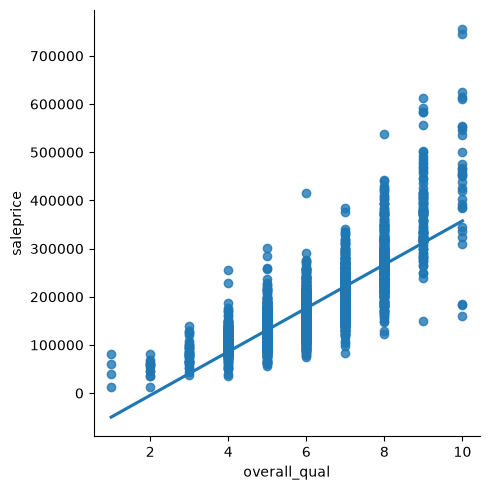

In [20]:
sns.lmplot(x="overall_qual", y="saleprice", data=prices, ci=None )

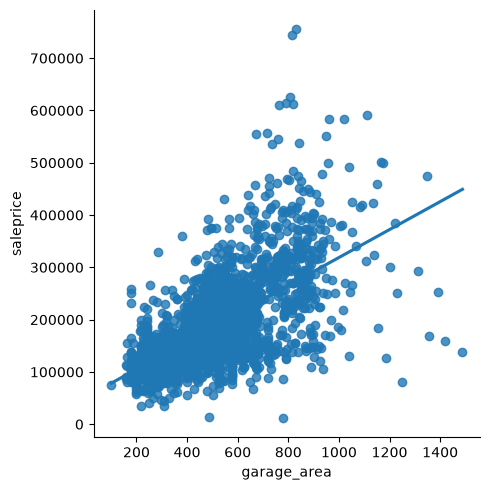

In [24]:
sns.lmplot(x="garage_area", y="saleprice", data=prices, ci=None )

<Axes: ylabel='Frequency'>

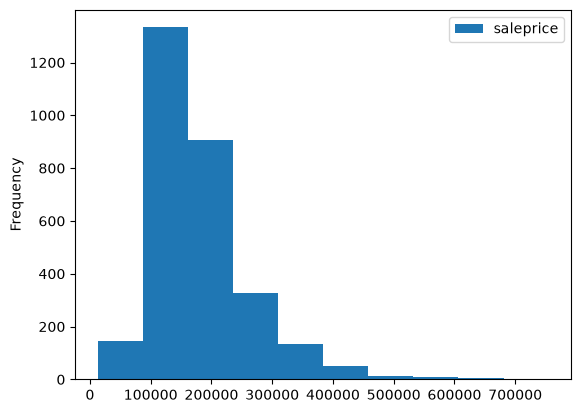

In [21]:
prices.plot.hist(y="saleprice")

In [51]:
prices[prices.isnull().any(axis=1)]

,lot_area,neighborhood,overall_qual,overall_cond,totrms_abvgrd,garage_yr_blt,garage_area,saleprice
27,10500,NAmes,4,5,5,NaN,0.0,115000
119,9320,NAmes,4,5,6,NaN,0.0,128950
125,13260,NAmes,5,6,10,NaN,0.0,84900
129,7207,BrkSide,5,7,4,NaN,0.0,116500
130,5350,BrkSide,3,2,6,NaN,0.0,76500
...,...,...,...,...,...,...,...,...
2913,1470,MeadowV,4,6,3,NaN,0.0,73000
2916,1533,MeadowV,5,7,3,NaN,0.0,92000
2918,1526,MeadowV,4,5,5,NaN,0.0,79500
2919,1936,MeadowV,4,7,5,NaN,0.0,90500


In [52]:
prices = prices.dropna()

In [53]:
train = prices[prices["overall_cond"]< 7].copy()
test = prices[prices["overall_cond"] >=7].copy()

In [37]:
train.shape

(2238, 7)

In [38]:
test.shape

(533, 7)

In [39]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()

In [40]:
predictors = ["overall_qual", "garage_area"]
target = "saleprice"

In [41]:
reg.fit(train[predictors], train["saleprice"])

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[37468.88, 129.03]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['overall_qual','garage_area']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.12e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


In [42]:
predictions = reg.predict(test[predictors])

In [43]:
predictions

array([167029.29324342, 251257.17025911, 174771.05647518, 274353.4305672 ,
       209272.26113846, 149688.9970772 , 118721.94415016, 108915.71072326,
       174125.9095392 , 174771.05647518, 200060.81636559, 137818.29345517,
       174771.05647518, 126979.8249307 , 153481.20758784, 116399.41518063,
       107109.29930252, 125123.055228  , 125947.58983314, 138592.46977834,
       115109.12130867, 149688.9970772 , 223078.40556843, 148965.17903598,
       114722.03314708, 149688.9970772 , 169609.88098734, 146463.2623973 ,
       106335.12297934, 137818.29345517, 143804.00354814, 106335.12297934,
       175287.17402396, 224935.17527113, 268289.04936898, 231931.075003  ,
       106026.705923  , 193351.2882314 , 190950.08815663,  63705.06692271,
       143804.00354814, 153094.11942625, 155882.40766261, 136062.24031638,
       162075.81824801, 195337.08732129, 133431.2942905 , 110206.00459522,
       129044.29512584, 151416.7373927 , 239336.10835513,  94156.00230097,
       173093.67444163, 1

In [54]:
test["predictions"] = predictions

In [55]:
test

,lot_area,neighborhood,overall_qual,overall_cond,totrms_abvgrd,garage_yr_blt,garage_area,saleprice,predictions
11,7980,Gilbert,6,7,6,1992.0,420.0,185000,167029.293243
16,12134,Gilbert,8,7,8,1988.0,492.0,164000,251257.170259
23,11241,NAmes,6,7,5,1970.0,480.0,149000,174771.056475
63,11764,NoRidge,8,7,9,1999.0,671.0,290000,274353.430567
79,9453,SawyerW,7,7,7,1993.0,457.0,194500,209272.261138
...,...,...,...,...,...,...,...,...,...
2867,14115,Crawfor,6,7,6,1956.0,470.0,230000,173480.762603
2869,15600,Crawfor,5,7,9,1950.0,342.0,257000,119496.120473
2873,7000,IDOTRR,6,7,6,1950.0,506.0,145400,178125.820542
2911,10172,Mitchel,5,7,5,1968.0,288.0,126500,112528.533565


In [56]:
test["predictions"] = test["predictions"].round()

In [57]:
test

,lot_area,neighborhood,overall_qual,overall_cond,totrms_abvgrd,garage_yr_blt,garage_area,saleprice,predictions
11,7980,Gilbert,6,7,6,1992.0,420.0,185000,167029.0
16,12134,Gilbert,8,7,8,1988.0,492.0,164000,251257.0
23,11241,NAmes,6,7,5,1970.0,480.0,149000,174771.0
63,11764,NoRidge,8,7,9,1999.0,671.0,290000,274353.0
79,9453,SawyerW,7,7,7,1993.0,457.0,194500,209272.0
...,...,...,...,...,...,...,...,...,...
2867,14115,Crawfor,6,7,6,1956.0,470.0,230000,173481.0
2869,15600,Crawfor,5,7,9,1950.0,342.0,257000,119496.0
2873,7000,IDOTRR,6,7,6,1950.0,506.0,145400,178126.0
2911,10172,Mitchel,5,7,5,1968.0,288.0,126500,112529.0


In [59]:
from sklearn.metrics import mean_absolute_error
error = mean_absolute_error(test["saleprice"], test["predictions"])

In [60]:
error

29900.285178236398

In [ ]:
#within 30 thousand dollars not too bad

In [61]:
prices.describe()["saleprice"]

count      2771.000000
mean     185111.697582
std       79609.482543
min       12789.000000
25%      133000.000000
50%      165000.000000
75%      217000.000000
max      755000.000000
Name: saleprice, dtype: float64

In [62]:
29900.285178236398 < 79609.482543

True

In [63]:
#Error is less than stardard deviation which is better than Trial 2

In [64]:
test[test["neighborhood"] == "NAmes"]

,lot_area,neighborhood,overall_qual,overall_cond,totrms_abvgrd,garage_yr_blt,garage_area,saleprice,predictions
23,11241,NAmes,6,7,5,1970.0,480.0,149000,174771.0
123,14112,NAmes,5,7,6,1964.0,484.0,180500,137818.0
124,8800,NAmes,6,7,6,1963.0,480.0,137500,174771.0
127,9724,NAmes,5,7,7,1994.0,400.0,197600,126980.0
134,11380,NAmes,6,8,5,1966.0,315.0,178000,153481.0
...,...,...,...,...,...,...,...,...,...
2586,7700,NAmes,5,7,6,1993.0,684.0,127000,163624.0
2609,9786,NAmes,6,7,7,1962.0,440.0,159000,169610.0
2614,7100,NAmes,5,7,5,1957.0,308.0,129900,115109.0
2617,18275,NAmes,7,8,9,1962.0,441.0,277500,207208.0


In [65]:
errors = (test["saleprice"] - predictions).abs()

In [66]:
errors

11       17970.706757
16       87257.170259
23       25771.056475
63       15646.569433
79       14772.261138
            ...      
2867     56519.237397
2869    137503.879527
2873     32725.820542
2911     13971.466435
2924     18688.997077
Name: saleprice, Length: 533, dtype: float64

In [68]:
error_by_neighborhood = errors.groupby(test["neighborhood"]).mean()

In [69]:
error_by_neighborhood 

neighborhood
BrDale     24692.574563
BrkSide    28312.957133
ClearCr    47380.972662
CollgCr    13901.809412
Crawfor    45688.229534
Edwards    38688.736168
Gilbert    34832.616504
IDOTRR     27696.101761
MeadowV    17507.105919
Mitchel    18940.511340
NAmes      25856.035285
NPkVill    51466.205705
NWAmes     31872.884431
NoRidge    36011.369558
OldTown    31562.762870
SWISU      31584.635659
Sawyer     19831.145947
SawyerW    23059.579820
StoneBr    23663.357663
Timber     54501.322841
Veenker    39398.399209
Name: saleprice, dtype: float64

In [70]:
saleprice_by_neighborhood =test["saleprice"].groupby(test["neighborhood"]).mean()

In [72]:
error_ratio = error_by_neighborhood / saleprice_by_neighborhood

In [73]:
error_ratio

neighborhood
BrDale     0.209481
BrkSide    0.210674
ClearCr    0.210732
CollgCr    0.099107
Crawfor    0.212565
Edwards    0.238407
Gilbert    0.195689
IDOTRR     0.236770
MeadowV    0.155481
Mitchel    0.130639
NAmes      0.170576
NPkVill    0.367616
NWAmes     0.147337
NoRidge    0.117915
OldTown    0.219438
SWISU      0.204123
Sawyer     0.141987
SawyerW    0.117591
StoneBr    0.099010
Timber     0.257487
Veenker    0.160954
Name: saleprice, dtype: float64

<Axes: ylabel='Frequency'>

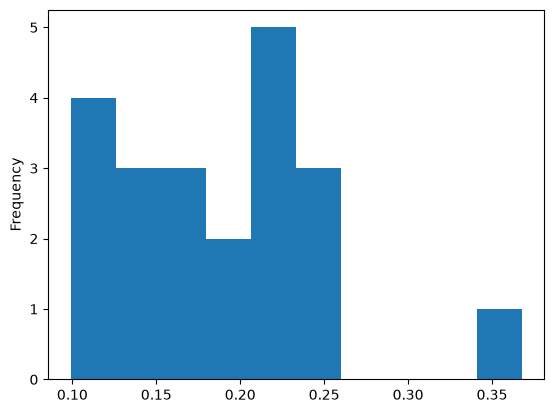

In [74]:
error_ratio.plot.hist()

In [75]:
error_ratio.sort_values()

neighborhood
StoneBr    0.099010
CollgCr    0.099107
SawyerW    0.117591
NoRidge    0.117915
Mitchel    0.130639
Sawyer     0.141987
NWAmes     0.147337
MeadowV    0.155481
Veenker    0.160954
NAmes      0.170576
Gilbert    0.195689
SWISU      0.204123
BrDale     0.209481
BrkSide    0.210674
ClearCr    0.210732
Crawfor    0.212565
OldTown    0.219438
IDOTRR     0.236770
Edwards    0.238407
Timber     0.257487
NPkVill    0.367616
Name: saleprice, dtype: float64